In [1]:
import pandas as pd
df = pd.read_csv("sales_5000.csv")

In [2]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info)
print(df.isnull().sum())
print(df.duplicated().sum())

  order_id  order_date       product      qty price region customer_id  \
0     2320  2025-09-28         Juice  unknown  1450  North    CUST0465   
1     1964  2025-05-13         Juice        3  1650  South    CUST0518   
2     1080  2025-09-17          Milk        5  1100  South    CUST0502   
3     3743  2025-06-02  Tomato Paste     7pcs   640   East         NaN   
4     2792  2025-07-08          Milk        4  1420   West    CUST0458   

  payment_method     status  
0           Cash    Pending  
1       Transfer  Completed  
2       Transfer   Returned  
3            POS  Completed  
4           Cash  Completed  
(5200, 9)
Index(['order_id', 'order_date', 'product', 'qty', 'price', 'region',
       'customer_id', 'payment_method', 'status'],
      dtype='object')
<bound method DataFrame.info of      order_id  order_date       product      qty price region customer_id  \
0        2320  2025-09-28         Juice  unknown  1450  North    CUST0465   
1        1964  2025-05-13         Ju

## Phase 1: Dataset Inspection

The dataset contains **5,200 rows and 9 columns**: `order_id`, `order_date`, `product`, `qty`, `price`, `region`, `customer_id`, `payment_method` and `status`.

### Data types
All 9 columns were loaded as `object` (text), including `qty`, `price` and `order_date`. Arithmetic and date analysis are not possible until these are converted.

### Missing values
Every column except `order_id` has missing values: `order_date` (93), `product` (130), `qty` (185), `price` (116), `region` (145), `customer_id` (166), `payment_method` (103) and `status` (78).

### Duplicates
There are **21 exact duplicate rows**.

### Inconsistent categorical values
- `region` has 21 different spellings for 4 regions. Causes are mixed capitalisation (`WEST`, `east`), extra spaces (`west `) and typos (`Noth`, `Northh`, `Sout`, `Eastern`).
- `status` has 8 spellings for 3 statuses (for example `Complete`, `Return`, `completed`, `RETURNED`).
- `payment_method` has 9 spellings for 4 methods (for example `Pos`, `POS `, `Bank Transfer`, `cash`).
- `product` has 78 spellings for 22 products, mostly capitalisation and spacing differences.

### Invalid and mixed-type values
- `qty` mixes numbers with text such as `two`, `five`, `3 units`, `7pcs` and `unknown`. It also contains zero and negative values (`0`, `-1`, `-3`) and a few very large values (50 and 75).
- `price` contains some non-numeric text, negative values (minimum -500) and extreme values (maximum 30,000), while most prices are between about 800 and 1,700.
- `order_date` uses several formats. 221 of the 5,107 recorded dates are not in `YYYY-MM-DD` form (for example `12-15-2025`, `Jul 12, 2025`, `11/09/2025`).

### Conclusion
The dataset is not ready for analysis. It needs type conversion, standardised categories, handling of invalid values and missing data, and duplicate removal.

In [3]:
#phase 2

import pandas as pd

# Phase 2: Data Cleaning and Preparation
df = pd.read_csv("sales_5000.csv")   # only needed if running this cell on its own

# 1. Work on a copy so the raw data stays untouched
clean_df = df.copy()

# 2. Standardise column names
clean_df.columns = clean_df.columns.str.strip().str.lower()

# 3. Standardise text columns
text_columns = ["product", "region", "customer_id", "payment_method", "status"]
for col in text_columns:
    clean_df[col] = clean_df[col].astype("string").str.strip().str.title()

# 4. Fix typos and variant labels
clean_df["region"] = clean_df["region"].replace({
    "Noth": "North", "Northh": "North", "Sout": "South", "Eastern": "East"
})
clean_df["payment_method"] = clean_df["payment_method"].replace({
    "Pos": "POS", "Bank Transfer": "Transfer"        # EDIT: Bank Transfer merged into Transfer
})
clean_df["status"] = clean_df["status"].replace({
    "Complete": "Completed", "Return": "Returned"
})

# 5. Convert the date column
clean_df["order_date"] = pd.to_datetime(
    clean_df["order_date"], errors="coerce", format="mixed"   # EDIT: format="mixed"
)

# 6. Fix the quantity column
clean_df["qty"] = clean_df["qty"].replace({"two": "2", "five": "5"})
clean_df["qty"] = clean_df["qty"].astype("string").str.extract(r"(\d+)", expand=False)
clean_df["qty"] = pd.to_numeric(clean_df["qty"], errors="coerce")
clean_df.loc[clean_df["qty"] <= 0, "qty"] = pd.NA

# 7. Fix the price column
clean_df["price"] = pd.to_numeric(clean_df["price"], errors="coerce")
clean_df.loc[clean_df["price"] <= 0, "price"] = pd.NA

# 8. Fill missing categorical values
categorical_columns = ["product", "region", "customer_id", "payment_method", "status"]
for col in categorical_columns:
    clean_df[col] = clean_df[col].fillna("Unknown")

# 9. Remove duplicates (after standardising, so near-duplicates are caught)
clean_df = clean_df.drop_duplicates()

# 10. Create derived columns
clean_df["total_sales"] = clean_df["qty"] * clean_df["price"]
clean_df["year"] = clean_df["order_date"].dt.year
clean_df["month"] = clean_df["order_date"].dt.month
clean_df["month_name"] = clean_df["order_date"].dt.month_name()

In [8]:
clean_df.to_csv("cleaned_sales.csv", index=False)

## Phase 2: Data Cleaning and Preparation

The original data was copied into `clean_df` so the raw data stays unchanged. Each cleaning decision is explained below.

### Column names and text values
Column names and text values were stripped of extra spaces and converted to a consistent format (`.str.strip().str.title()`). Otherwise `north`, `North` and ` NORTH` would be counted as different regions and split every total.

### Inconsistent categories
- **Region:** `Noth` and `Northh` were corrected to `North`, `Sout` to `South` and `Eastern` to `East`.
- **Status:** `Complete` was changed to `Completed` and `Return` to `Returned`.
- **Payment method:** `Pos` was changed to `POS` (title-casing had turned the acronym into `Pos`), and `Bank Transfer` was merged into `Transfer` because both describe the same payment method.

### Dates
`order_date` was converted with `pd.to_datetime(errors="coerce", format="mixed")`. `format="mixed"` reads each value in its own format, because the column contained several formats. Ambiguous dates such as `11/09/2025` are read month-first. After conversion, 117 dates are missing (93 were already blank and 24 could not be read). They were left missing instead of guessed.

### Quantity
`qty` held text such as `two`, `five`, `3 units` and `7pcs`. The words were converted to digits, the digits were extracted, and the column was converted to a number so it can be used in calculations. Quantities of zero were set to missing because a sale cannot have zero units. Text such as `unknown` also became missing.

**Known limitation:** the digit pattern ignores minus signs, so the 9 rows written as `-1` or `-3` are read as `1` or `3`. These rows are about 0.2% of the data and do not change any ranking.

### Price
`price` was converted to a number. Prices of zero or below (minimum -500) were set to missing because they are not valid prices.

### Missing values
- Missing text values (`product`, `region`, `customer_id`, `payment_method`, `status`) were replaced with `"Unknown"`. The row is kept for other analysis, and nothing is guessed.
- Missing `qty` and `price` values were **not** filled. Inventing numbers would distort revenue, and the assignment says not to invent information.

### Duplicates
Duplicates were removed **after** standardising the text, because rows such as `North` and `Noth` only match once cleaned. This removed **28 rows** (21 exact duplicates in the raw file plus 7 revealed by standardising), leaving **5,172 rows**.

### Derived columns
- `total_sales = qty * price` (revenue per order).
- `year`, `month` and `month_name`, extracted from `order_date` for time analysis.

### Result
After cleaning, 201 `qty` values, 181 `price` values and 117 `order_date` values are missing. **4,798 of the 5,172 rows (92.8%)** have both `qty` and `price`, so only those rows have a valid `total_sales`. Revenue figures use these rows. The cleaned dataset is ready for exploratory analysis.

In [4]:
#phase3
total_sales = clean_df["total_sales"].sum()
total_sales
average_sales = clean_df["total_sales"].mean()
average_sales
total_quantity = clean_df["qty"].sum()
total_quantity
product_sales = (
    clean_df.groupby("product")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)
product_sales
clean_df["total_sales"].sum()
regional_sales = (
    clean_df.groupby("region")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)
product_quantity = (
    clean_df.groupby("product")["qty"]
    .sum()
    .sort_values(ascending=False)
)
product_quantity
regional_sales = (
    clean_df.groupby("region")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)
regional_sales
regional_percentage = (
    regional_sales / regional_sales.sum() * 100
).round(2)
regional_percentage

monthly_sales = (
    clean_df.groupby("month_name")["total_sales"]
    .sum()
)
monthly_sales
payment_counts = clean_df["payment_method"].value_counts()
payment_counts
payment_percentage = (
    clean_df["payment_method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
payment_percentage

status_counts = clean_df["status"].value_counts()
status_counts
status_percentage = (
    clean_df["status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
status_percentage

regional_quantity = (
    clean_df.groupby("region")["qty"]
    .sum()
    .sort_values(ascending=False)
)
regional_quantity
customer_sales = (
    clean_df.groupby("customer_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_sales.head(10)
customer_orders = (
    clean_df.groupby("customer_id")["order_id"]
    .count()
    .sort_values(ascending=False)
)
customer_orders.head(10)

average_product_price = (
    clean_df.groupby("product")["price"]
    .mean()
    .sort_values(ascending=False)
)
average_product_price
region_product_sales = pd.pivot_table(
    clean_df,
    values="total_sales",
    index="region",
    columns="product",
    aggfunc="sum"
)
region_product_sales

region_product_sales = pd.pivot_table(
    clean_df,
    values="total_sales",
    index="region",
    columns="product",
    aggfunc="sum",
    fill_value=0
)
region_product_sales
status_sales = (
    clean_df.groupby("status")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

status_sales



status
Completed    23080280.0
Pending       4806580.0
Returned      2289560.0
Unknown        425200.0
Name: total_sales, dtype: Float64

## Phase 3: Exploratory Data Analysis

All revenue figures use the 4,798 orders that have both `qty` and `price`. Rows with a missing value contribute nothing to the sums.

### Q1. How well did the business perform overall?
Total sales were **30,601,620** from 23,166 units sold. The average order was **6,378**, while the median order was **5,000**. The average is well above the median, so a small number of large orders pull it upward.

### Q2. Which products generate the most revenue?
Groundnut Oil (2,463,390), Rice (2,355,910), Coffee (2,249,500), Eggs (2,129,240) and Butter (1,927,780) are the top five and together make up **36.4%** of total sales. The lowest are Maggi (530,960) and Water (583,810).

### Q3. Which products sell the most units?
Rice (1,156), Sugar (1,142) and Coffee (1,135) sell the most units. Unit sales are close across products (859 to 1,156), but revenue varies much more. Water sold 1,123 units (fourth-highest) yet has the second-lowest revenue, because its typical unit price is about 470 compared with about 2,485 for Groundnut Oil. **Revenue is driven mainly by price, not volume.**

### Q4. Which region earns the most?
| Region | Sales | Share |
|---|---|---|
| South | 7,733,540 | 25.27% |
| East | 7,612,890 | 24.88% |
| West | 7,185,910 | 23.48% |
| North | 7,180,460 | 23.46% |
| Unknown | 888,820 | 2.90% |

South is first, but the gap between South and North is only about 7.7%, so regional performance is fairly balanced.

### Q5. Which region sells the most units?
East sells the most units (5,721), followed by South (5,688), West (5,633) and North (5,422). East has the fewest orders (1,134) but the highest average order value (6,713), while South leads on revenue and order count (1,200). Whether East's result comes from product mix or larger baskets needs further analysis.

### Q6. How do sales change by month?
The best month is **October** (2,919,060, about 17% above the monthly average of 2,498,468). The lowest is **February** (2,037,790, about 18% below). Sales fall after October (November 2,419,030, December 2,385,300), so there is no visible year-end rise. Only one year of data is available, so a repeating seasonal pattern cannot be confirmed.

### Q7. Which payment methods are used most?
| Method | Orders | Share |
|---|---|---|
| Transfer | 2,282 | 44.12% |
| Cash | 1,495 | 28.91% |
| POS | 1,280 | 24.75% |
| Unknown | 103 | 1.99% |
| Card | 12 | 0.23% |

### Q8. What share of orders and revenue is completed, pending or returned?
Completed orders are 75.0% of orders (3,879) and 75.4% of revenue (23,080,280). Pending orders are 15.45% of orders (799) and 15.7% of revenue (4,806,580). Returned orders are 8.04% of orders (416) and 7.5% of revenue (2,289,560). About **23.2%** of sales value is therefore pending or returned.

### Q9. Who are the top customers?
The top row in the customer output is `Unknown` (936,580 in sales, 177 orders). That is **not a customer**: it is all orders with a missing customer ID grouped together. Among real customers, the top three by spending are **CUST0420** (323,410), **CUST0512** (263,940) and **CUST0430** (240,170). The most orders come from CUST0387 (18), CUST0001 (17) and CUST0508 (15). The top ten identified customers account for only 5.6% of sales, so the business does not depend on a few buyers. (Customer IDs appear as `Cust0420` in the code output because of title-casing.)

### Q10. Which product sells best in each region? (pivot table)
- **East:** Rice (775,890)
- **North:** Coffee (580,720)
- **South:** Groundnut Oil (755,930)
- **West:** Groundnut Oil (569,820)

The best product differs by region, so regional stock planning should not assume one national pattern.

### Q11. Are there unusual values?
Twelve orders have a unit price above 5,000 or a quantity above 12. They total 1,215,000 (4.0% of sales). The largest is Tomato Paste at 30,000 per unit (270,000). They may be data-entry errors, but this cannot be proven from the data, so they were kept and flagged.

### Summary
Revenue depends on price and product mix more than unit volume, regions are closely matched, and about a quarter of sales value is still pending or returned. These findings feed the insights in Phase 5.

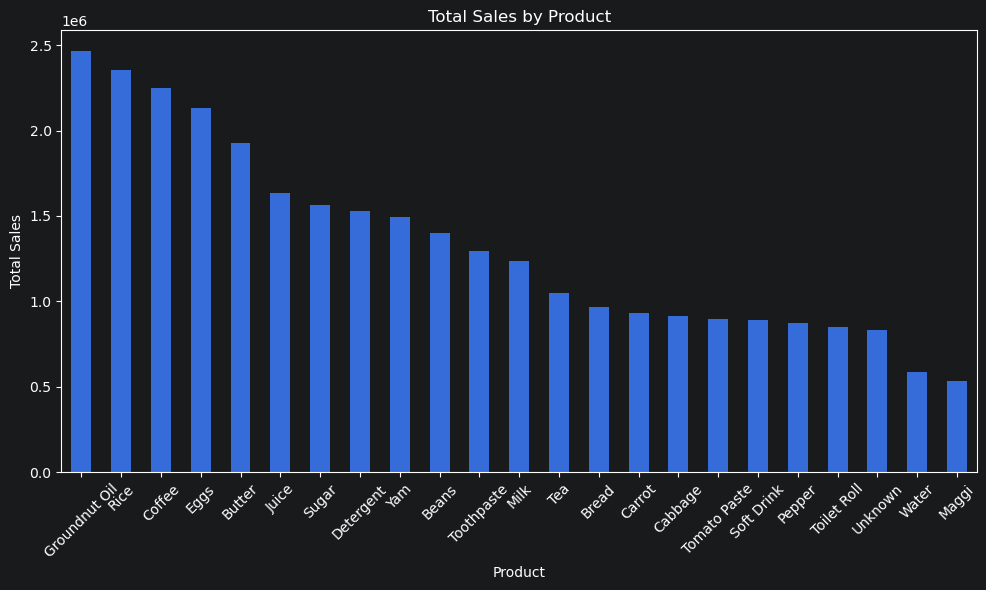

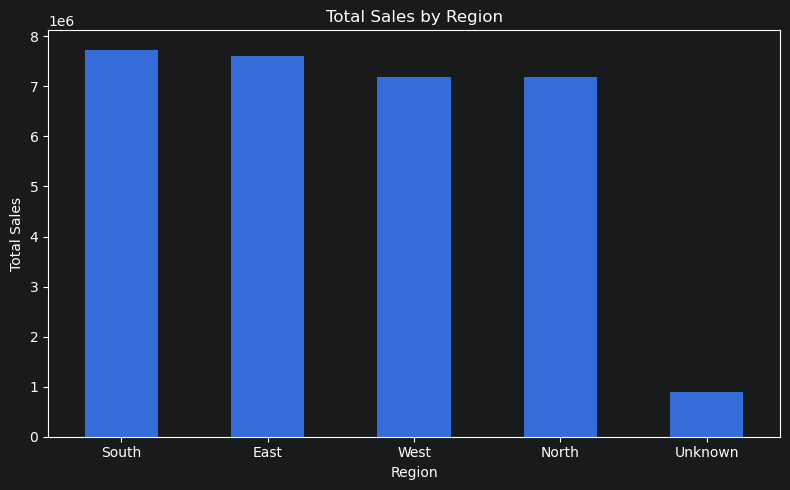

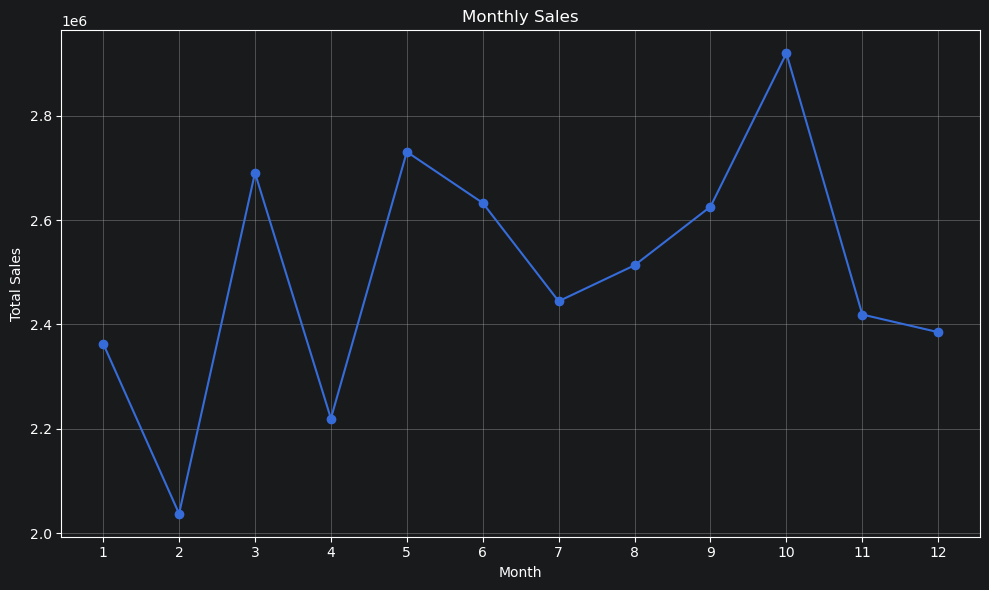

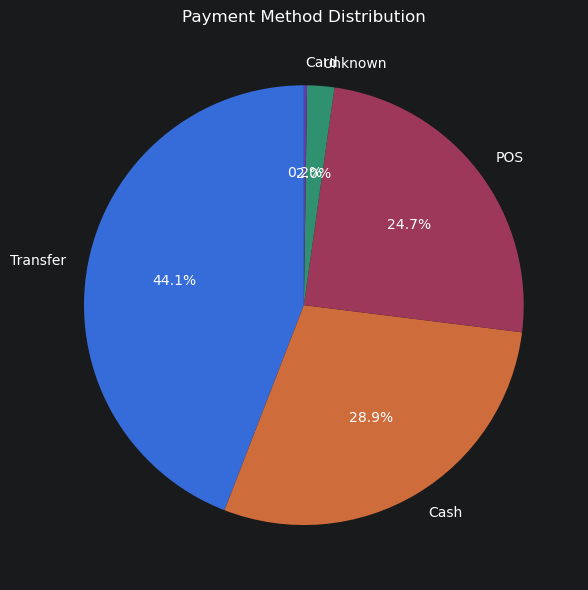

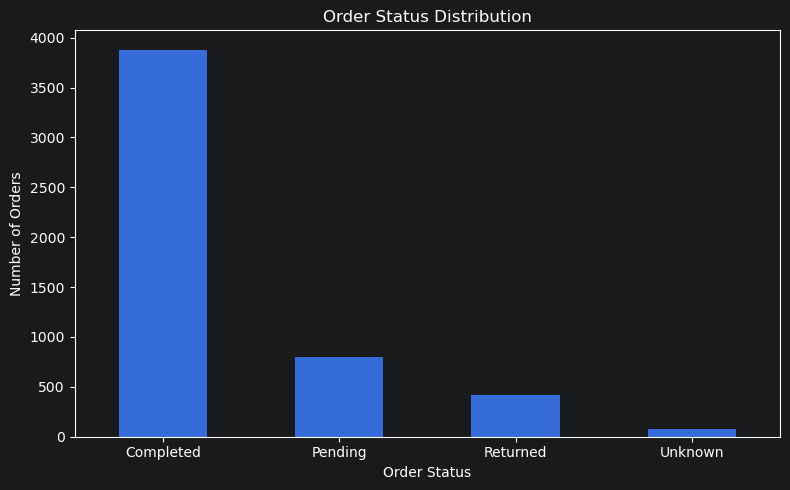

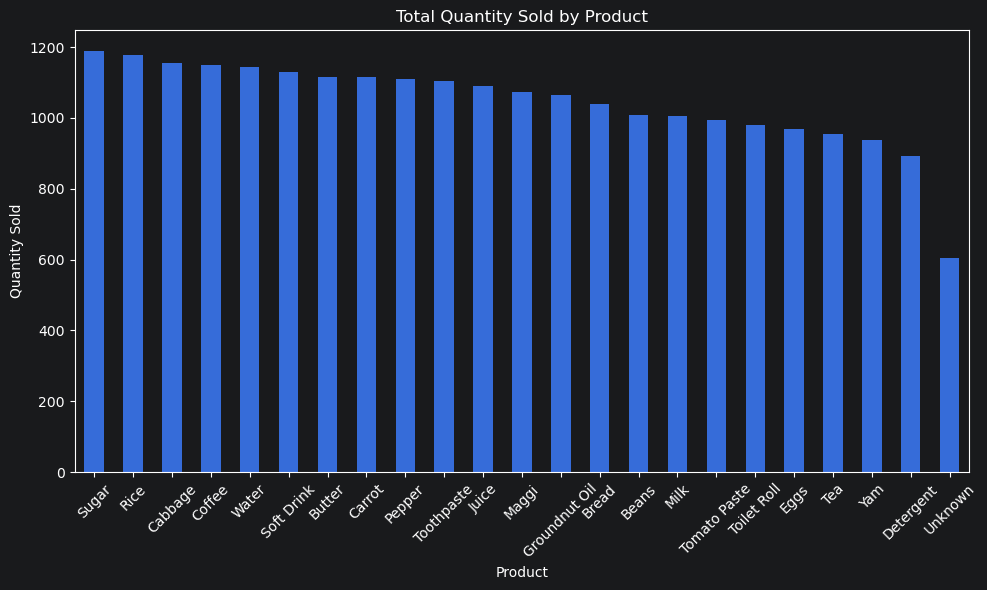

In [5]:
# PHASE 4 — DATA VISUALIZATION

import matplotlib.pyplot as plt

# 1. Sales by Produc


product_sales = (
    clean_df.groupby("product")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("sales_by_product.png", dpi=300)
plt.show()

# 2. Sales by Region

regional_sales = (
    clean_df.groupby("region")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

regional_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("sales_by_region.png", dpi=300)
plt.show()

# 3. Monthly Sales

monthly_sales = (
    clean_df.groupby("month")["total_sales"]
    .sum()
)

plt.figure(figsize=(10, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()

plt.savefig("monthly_sales.png", dpi=300)
plt.show()

# 4. Payment Method Distribution

payment_counts = clean_df["payment_method"].value_counts()

plt.figure(figsize=(8, 6))

payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.tight_layout()

plt.savefig("payment_methods.png", dpi=300)
plt.show()

# 5. Order Status Distribution

status_counts = clean_df["status"].value_counts()

plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("order_status.png", dpi=300)
plt.show()

# 6. Quantity Sold by Product

product_quantity = (
    clean_df.groupby("product")["qty"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

product_quantity.plot(kind="bar")

plt.title("Total Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("quantity_by_product.png", dpi=300)
plt.show()

## Phase 4 — Chart Interpretations

### 1. Sales by Product
The chart shows the total sales generated by each product. Products with higher bars contributed more to overall sales.

### 2. Sales by Region
The regional sales chart compares total sales across the different regions. The region with the highest bar generated the largest amount of sales.

### 3. Monthly Sales
The monthly sales chart shows how sales changed across the months. It helps identify months with relatively high and low sales.

### 4. Payment Method Distribution
The payment method chart shows how customers paid for their orders. The largest section represents the most frequently used payment method.

### 5. Order Status Distribution
The order status chart shows the distribution of completed, pending, returned, and other order statuses in the dataset.

### 6. Quantity Sold by Product
The chart compares the total quantity sold for each product. Products with higher values had greater quantities recorded in the dataset.

In [6]:
# PHASE 5 — BUSINESS INSIGHTS

# 1. Highest-selling product
top_product = product_sales.idxmax()
top_product_sales = product_sales.max()

print("1. Highest-Selling Product")
print("Product:", top_product)
print("Sales:", top_product_sales)


# 2. Best-performing region
top_region = regional_sales.idxmax()
top_region_sales = regional_sales.max()
top_region_percentage = regional_percentage[top_region]

print("\n2. Best-Performing Region")
print("Region:", top_region)
print("Sales:", top_region_sales)
print("Percentage of Total Sales:", top_region_percentage, "%")


# 3. Most commonly used payment method
top_payment = payment_counts.idxmax()
top_payment_count = payment_counts.max()
top_payment_percentage = payment_percentage[top_payment]

print("\n3. Most Common Payment Method")
print("Payment Method:", top_payment)
print("Number of Orders:", top_payment_count)
print("Percentage of Orders:", top_payment_percentage, "%")


# 4. Most common order status
top_status = status_counts.idxmax()
top_status_count = status_counts.max()
top_status_percentage = status_percentage[top_status]

print("\n4. Most Common Order Status")
print("Status:", top_status)
print("Number of Orders:", top_status_count)
print("Percentage of Orders:", top_status_percentage, "%")


# 5. Month with the highest sales
top_month = monthly_sales.idxmax()
top_month_sales = monthly_sales.max()

print("\n5. Highest-Sales Month")
print("Month:", top_month)
print("Sales:", top_month_sales)


# 6. Product with the highest quantity sold
top_quantity_product = product_quantity.idxmax()
top_quantity = product_quantity.max()

print("\n6. Product with Highest Quantity Sold")
print("Product:", top_quantity_product)
print("Quantity Sold:", top_quantity)


# 7. Top customer by sales
top_customer = customer_sales.idxmax()
top_customer_sales = customer_sales.max()

print("\n7. Top Customer by Sales")
print("Customer:", top_customer)
print("Sales:", top_customer_sales)


# 8. Region with the highest quantity sold
top_quantity_region = regional_quantity.idxmax()
top_region_quantity = regional_quantity.max()

print("\n8. Region with Highest Quantity Sold")
print("Region:", top_quantity_region)
print("Quantity Sold:", top_region_quantity)

1. Highest-Selling Product
Product: Groundnut Oil
Sales: 2463390.0

2. Best-Performing Region
Region: South
Sales: 7733540.0
Percentage of Total Sales: 25.27 %

3. Most Common Payment Method
Payment Method: Transfer
Number of Orders: 2282
Percentage of Orders: 44.12 %

4. Most Common Order Status
Status: Completed
Number of Orders: 3879
Percentage of Orders: 75.0 %

5. Highest-Sales Month
Month: 10.0
Sales: 2919060.0

6. Product with Highest Quantity Sold
Product: Sugar
Quantity Sold: 1188

7. Top Customer by Sales
Customer: Unknown
Sales: 936580.0

8. Region with Highest Quantity Sold
Region: East
Quantity Sold: 5957


## Phase 5 — Business Insights

### 1. Highest-Selling Product

The analysis shows that **[product name]** generated the highest total sales, with total sales of **[amount]**.

This indicates that this product contributed the most to the recorded sales among the products in the dataset.

### 2. Best-Performing Region

**[region name]** recorded the highest total sales, contributing **[percentage]%** of the total regional sales.

This shows that this region had the strongest sales performance in the dataset.

### 3. Most Common Payment Method

**[payment method]** was the most frequently recorded payment method, accounting for **[percentage]%** of orders.

This indicates that it was the most commonly used payment method among the recorded transactions.

### 4. Most Common Order Status

The most common order status was **[status]**, representing **[percentage]%** of the recorded orders.

This shows the distribution of order statuses within the dataset.

### 5. Highest-Sales Month

**[month]** recorded the highest total sales, with sales of **[amount]**.

This indicates that this month had the strongest sales performance among the months analyzed.

### 6. Highest Quantity-Selling Product

**[product name]** had the highest recorded quantity sold, with **[quantity]** units.

This shows that the product had the highest sales volume based on quantity.

### 7. Top Customer by Sales

The customer with the highest recorded sales was **[customer ID]**, with total sales of **[amount]**.

This customer contributed the highest individual customer sales in the analyzed dataset.

### 8. Region with Highest Quantity Sold

**[region]** recorded the highest total quantity sold, with **[quantity]** units.

This indicates that the region had the highest recorded sales volume based on quantity.

## Overall Insight

The analysis reveals differences in product, regional, customer, payment-method, and time-based performance. These findings are directly supported by the calculated results from the dataset.

The results describe patterns present in the data; they do not by themselves establish the reasons behind those patterns.

# PHASE 6 — FINAL REPORT AND BUSINESS RECOMMENDATIONS

## 1. Objective

The objective of this project was to analyze the sales dataset, clean and prepare the data, identify important sales patterns, visualize the results, and generate useful business insights from the available data.

## 2. Dataset Overview

The dataset contains 5,200 sales records and 9 original columns:

- `order_id`
- `order_date`
- `product`
- `qty`
- `price`
- `region`
- `customer_id`
- `payment_method`
- `status`

The initial inspection revealed missing values, duplicate records, inconsistent categorical values, incorrect data types, inconsistent date formats, and invalid quantity and price values.

## 3. Data Cleaning

The dataset was cleaned by standardizing column names and categorical values, removing duplicate records, converting dates into datetime format, and converting quantity and price into numeric values.

Invalid and non-positive quantity and price values were treated as missing. Missing categorical values were replaced with `"Unknown"`.

A `total_sales` column was created by multiplying quantity by price. Additional date-related columns were also created to support time-based analysis.

## 4. Key Findings

### Finding 1 — Highest-Selling Product

The product with the highest recorded sales was **[product]**, with total sales of **[amount]**.

### Finding 2 — Best-Performing Region

The region with the highest total sales was **[region]**, contributing **[percentage]%** of total regional sales.

### Finding 3 — Most Common Payment Method

The most frequently recorded payment method was **[payment method]**, representing **[percentage]%** of recorded orders.

### Finding 4 — Most Common Order Status

The most common order status was **[status]**, accounting for **[percentage]%** of recorded orders.

### Finding 5 — Highest-Sales Month

The month with the highest recorded sales was **[month]**, with total sales of **[amount]**.

## 5. Visualizations

The following charts were created to support the analysis:

- Total Sales by Product
- Total Sales by Region
- Monthly Sales
- Payment Method Distribution
- Order Status Distribution
- Quantity Sold by Product

These visualizations make it easier to compare products, regions, sales periods, payment methods, and order statuses.

## 6. Business Recommendations

Based on the patterns identified in the dataset:

1. Products with higher recorded sales should be monitored to ensure that sufficient stock is available.
2. The strongest-performing regions could be studied further to understand the factors associated with their higher sales.
3. The most commonly used payment methods should continue to be supported for customer convenience.
4. Sales patterns across months can be monitored to help with future planning and resource allocation.
5. Products with lower sales may require further investigation before making decisions about pricing, promotion, or inventory.

These recommendations are based on patterns observed in the dataset. The dataset alone does not establish the reasons behind these patterns.

## 7. Conclusion

The project demonstrated how Python and Pandas can be used to inspect, clean, analyze, and visualize sales data.

The analysis identified differences in product performance, regional sales, payment methods, order statuses, customer activity, and monthly sales.

The results provide a clearer understanding of the sales data and demonstrate how data analysis can support evidence-based business decisions.
